# EDA — Producción de hidrocarburos (Fase 3, ML)

**Rol 1 — ML Engineer.** Objetivo de este notebook: entender los datos de producción mensual
antes de definir el problema predictivo y el feature engineering. Las conclusiones de acá
alimentan el **ADR de diseño de modelado** (target, grano, universo de pozos, features y split temporal).

**Fuente:** `data/_explore/produccion_full.csv` (export de la capa de producción, grano pozo × mes).

> Las decisiones de modelado NO se toman acá: este notebook genera la **evidencia**. Las decisiones
> quedan registradas en el ADR correspondiente.

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
CSV = "../data/_explore/produccion_full.csv"  # ajustar si se corre desde otra carpeta

# Columnas relevantes para el EDA (el CSV completo tiene ~40 columnas)
cols = [
    "idpozo", "anio", "mes",
    "prod_pet", "prod_gas", "prod_agua", "tef",
    "tipopozo", "tipo_de_recurso", "formacion", "profundidad",
    "cuenca", "provincia", "areayacimiento", "empresa", "clasificacion",
]
df = pd.read_csv(CSV, usecols=cols, encoding="utf-8-sig")

# Tipados numéricos defensivos (el CSV trae strings en algunas medidas)
for c in ["prod_pet", "prod_gas", "prod_agua", "tef", "profundidad"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["periodo"] = pd.to_datetime(dict(year=df.anio, month=df.mes, day=1))
df.shape

(405996, 17)

## 1. Panorama general

¿Cuántos datos hay, de cuántos pozos y qué rango temporal cubren?

In [2]:
print(f"Filas (pozo-mes): {len(df):,}")
print(f"Pozos únicos:     {df.idpozo.nunique():,}")
print(f"Rango temporal:   {df.anio.min()} – {df.anio.max()}")
print(f"Meses distintos:  {df.groupby(['anio','mes']).ngroups}")
df.head()

Filas (pozo-mes): 405,996
Pozos únicos:     4,929
Rango temporal:   2006 – 2026
Meses distintos:  244


,anio,mes,idpozo,prod_pet,prod_gas,prod_agua,tef,tipopozo,empresa,profundidad,formacion,areayacimiento,cuenca,provincia,tipo_de_recurso,clasificacion,periodo
0,2016,1,135204,0.000,59.940,28.35,30.81,Gasífero,YSUR ENERGÍA ARGENTINA S.R.L.,3500.0,precuyo,ANTICLINAL CAMPAMENTO OESTE,NEUQUINA,Neuquén,NO CONVENCIONAL,EXPLOTACION,2016-01-01
1,2018,1,155584,80.806,786.902,0.00,31.00,Gasífero,YSUR ENERGÍA ARGENTINA S.R.L.,3847.0,lajas,ESTACION FERNANDEZ ORO,NEUQUINA,Rio Negro,NO CONVENCIONAL,EXPLOTACION,2018-01-01
2,2015,1,135203,0.000,0.000,0.00,0.00,Gasífero,YSUR ENERGÍA ARGENTINA S.R.L.,3617.0,precuyo,ANTICLINAL CAMPAMENTO OESTE,NEUQUINA,Neuquén,NO CONVENCIONAL,EXPLOTACION,2015-01-01
3,2017,1,155582,58.280,608.010,13.63,31.00,Gasífero,YSUR ENERGÍA ARGENTINA S.R.L.,3805.0,lajas,ESTACION FERNANDEZ ORO,NEUQUINA,Rio Negro,NO CONVENCIONAL,EXPLOTACION,2017-01-01
4,2016,1,136137,0.000,432.170,45.52,31.00,Gasífero,YSUR ENERGÍA ARGENTINA S.R.L.,3375.0,precuyo,GUANACO,NEUQUINA,Neuquén,NO CONVENCIONAL,EXPLOTACION,2016-01-01


## 2. Calidad de datos (nulos)

Qué tan completas están las columnas que nos importan.

In [3]:
nulos = (df.isna().mean() * 100).round(2).sort_values(ascending=False)
nulos.to_frame("% nulos")

,% nulos
clasificacion,0.22
tipopozo,0.15
anio,0.00
profundidad,0.00
tipo_de_recurso,0.00
provincia,0.00
cuenca,0.00
areayacimiento,0.00
formacion,0.00
empresa,0.00


## 3. El target candidato: `prod_pet` (producción de petróleo)

Miramos su distribución y, sobre todo, cuántos registros son **cero** — porque eso revela
que el dataset mezcla pozos que no producen petróleo.

= 0 (sin producción):  35.5%
> 0:                   64.5%
nulos:                  0.0%

Estadísticas de prod_pet > 0:
count    261948.00
mean        500.75
std        1105.53
min           0.00
25%           9.39
50%          50.95
75%         424.81
max       26593.26
Name: prod_pet, dtype: float64


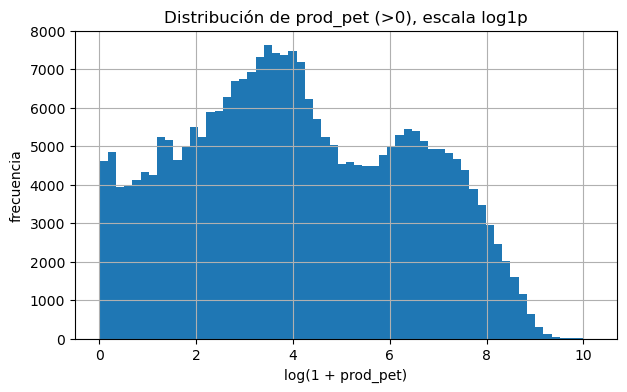

In [4]:
pet = df.prod_pet
print(f"= 0 (sin producción): {(pet==0).mean()*100:5.1f}%")
print(f"> 0:                  {(pet>0).mean()*100:5.1f}%")
print(f"nulos:                {pet.isna().mean()*100:5.1f}%")
print("\nEstadísticas de prod_pet > 0:")
print(pet[pet>0].describe().round(2))

# Histograma en escala log (la distribución es muy sesgada)
plt.figure(figsize=(7,4))
np.log1p(pet[pet>0]).hist(bins=60)
plt.title("Distribución de prod_pet (>0), escala log1p")
plt.xlabel("log(1 + prod_pet)"); plt.ylabel("frecuencia")
plt.show()

## 4. Tipos de pozo → definir el universo "petrolero"

El 35% de ceros no es ruido: hay pozos **gasíferos, de inyección y sumideros** que no producen
petróleo. Para un forecast de petróleo conviene **filtrar** a los pozos petroleros.

In [5]:
print("Registros por tipo de pozo:")
print(df.tipopozo.value_counts(dropna=False))

print("\n% de registros con prod_pet>0 por tipo de pozo:")
print((df.assign(pet_pos=df.prod_pet>0)
         .groupby("tipopozo").pet_pos.mean().mul(100).round(1)
         .sort_values(ascending=False)))

# tipo_de_recurso: ¿aporta info? (si tiene 1 solo valor, NO sirve como feature)
print("\ntipo_de_recurso (cardinalidad):", df.tipo_de_recurso.nunique(),
      "->", df.tipo_de_recurso.dropna().unique()[:5])

Registros por tipo de pozo:
tipopozo
Gasífero             221257
Petrolífero          156071
Otro tipo             27320
Sumidero                644
NaN                     605
Inyección de Agua        56
Inyección de Gas         43
Name: count, dtype: int64

% de registros con prod_pet>0 por tipo de pozo:
tipopozo
Petrolífero          85.8
Gasífero             57.9
Inyección de Gas     39.5
Sumidero              0.2
Otro tipo             0.1
Inyección de Agua     0.0
Name: pet_pos, dtype: float64

tipo_de_recurso (cardinalidad): 1 -> ['NO CONVENCIONAL']


In [6]:
# Universo petrolero: pozos con al menos un mes de producción de petróleo real.
pozos_pet = df.loc[df.prod_pet > 0, "idpozo"].unique()
dfp = df[df.idpozo.isin(pozos_pet)].copy()
print(f"Pozos petroleros: {len(pozos_pet):,} de {df.idpozo.nunique():,}")
print(f"Filas en el universo petrolero: {len(dfp):,}")

Pozos petroleros: 4,281 de 4,929
Filas en el universo petrolero: 347,063


## 5. Cobertura temporal por pozo

**Decisión clave:** para usar *lags* (producción de meses anteriores) y un split train/test temporal,
cada pozo necesita suficiente historia. ¿Alcanza para modelar a nivel pozo, o hay que subir a yacimiento?

count    4281.0
mean       81.1
std        57.7
min         1.0
25%        30.0
50%        78.0
75%       124.0
max       244.0
dtype: float64

Pozos petroleros con al menos X meses de historia:
  >=  12 meses:  3,883 ( 90.7%)
  >=  24 meses:  3,450 ( 80.6%)
  >=  36 meses:  3,021 ( 70.6%)
  >=  60 meses:  2,384 ( 55.7%)
  >= 120 meses:  1,195 ( 27.9%)


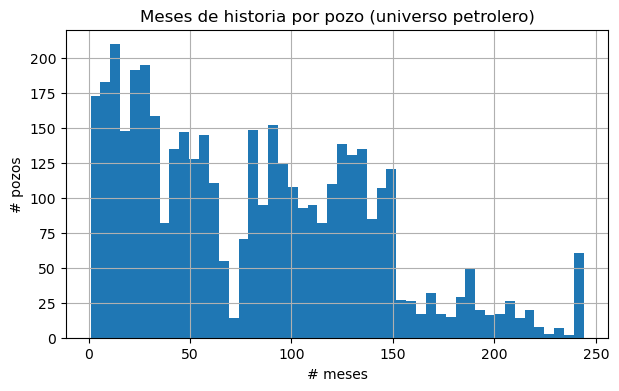

In [7]:
meses_por_pozo = dfp.groupby("idpozo").size()
print(meses_por_pozo.describe().round(1))
print("\nPozos petroleros con al menos X meses de historia:")
for k in [12, 24, 36, 60, 120]:
    c = (meses_por_pozo >= k).sum()
    print(f"  >= {k:>3} meses: {c:>6,} ({100*c/len(meses_por_pozo):5.1f}%)")

plt.figure(figsize=(7,4))
meses_por_pozo.hist(bins=50)
plt.title("Meses de historia por pozo (universo petrolero)")
plt.xlabel("# meses"); plt.ylabel("# pozos")
plt.show()

## 6. Comportamiento temporal (curvas de declinación)

Los pozos de hidrocarburos típicamente **declinan** con el tiempo. Visualizar algunas series
ayuda a entender qué features autoregresivas (lags, medias móviles, tendencia) tienen sentido.

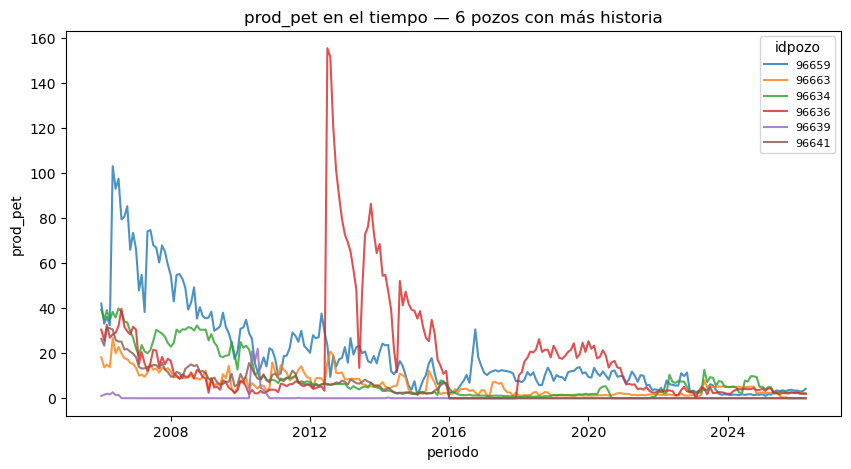

In [8]:
# Tomamos algunos pozos con buena historia y graficamos su prod_pet en el tiempo
top = meses_por_pozo.sort_values(ascending=False).head(6).index
plt.figure(figsize=(10,5))
for pid in top:
    s = (dfp[dfp.idpozo == pid].sort_values("periodo").set_index("periodo").prod_pet)
    plt.plot(s.index, s.values, label=str(pid), alpha=0.8)
plt.title("prod_pet en el tiempo — 6 pozos con más historia")
plt.xlabel("periodo"); plt.ylabel("prod_pet"); plt.legend(title="idpozo", fontsize=8)
plt.show()

## 7. Análisis para el split temporal

El split debe respetar el tiempo (entrenar con pasado, validar/testear con futuro).
Estrategia a documentar en el ADR: **dev / test** primero, y **train / val dentro de dev**.

```
|<---------------- DEV ---------------->|<---- TEST ---->|
|<----- TRAIN ----->|<----- VAL ----->|
   (pasado)            (más reciente)      (lo más nuevo)
```

Miramos cuántos registros hay por año para elegir los cortes de fecha.

Registros (pozo-mes) por año en el universo petrolero:
anio
2006     2020
2007     2094
2008     1976
2009     1489
2010     1802
2011     2292
2012     3278
2013     4607
2014     7584
2015    11068
2016    14718
2017    17452
2018    20862
2019    24261
2020    26623
2021    29168
2022    33119
2023    36986
2024    41731
2025    47082
2026    16851
dtype: int64


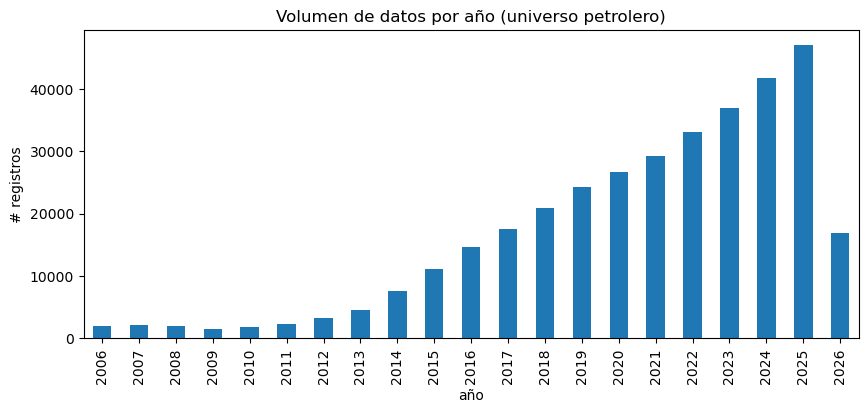

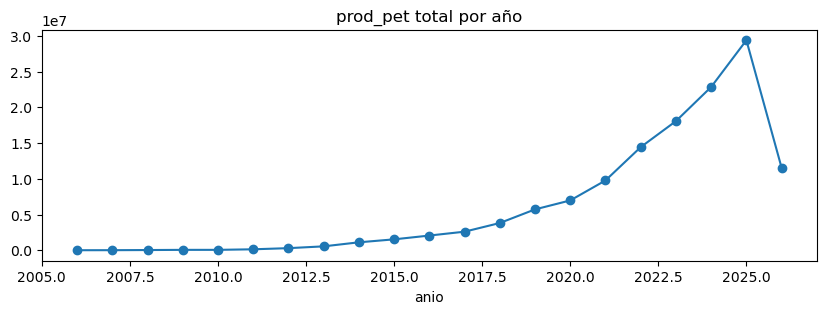

In [9]:
reg_por_anio = dfp.groupby("anio").size()
print("Registros (pozo-mes) por año en el universo petrolero:")
print(reg_por_anio)

plt.figure(figsize=(10,4))
reg_por_anio.plot(kind="bar")
plt.title("Volumen de datos por año (universo petrolero)")
plt.xlabel("año"); plt.ylabel("# registros")
plt.show()

# Producción total por año (otra mirada para detectar años atípicos / parciales)
dfp.groupby("anio").prod_pet.sum().plot(figsize=(10,3), marker="o",
    title="prod_pet total por año")
plt.show()

## 8. Features candidatas (resumen)

A confirmar con el Rol 2 (feature store). Cada una mapeada a su columna de origen:

| Feature | Origen | Tipo |
|---|---|---|
| `prod_pet` lag 1, 2, 3 | autoregresivo de `prod_pet` | numérica |
| media móvil 3m de `prod_pet` | autoregresivo | numérica |
| `tef` (lag 1) | `tef` | numérica |
| antigüedad del pozo (meses) | derivada de `periodo` | numérica |
| `profundidad` | `dim_pozo` | numérica |
| `formacion` | `dim_pozo` | categórica |
| `tipopozo`, `clasificacion` | `dim_pozo` | categórica |
| `cuenca`, `provincia` | `dim_yacimiento` | categórica |
| `empresa`/operadora | `dim_operadora` | categórica |
| `mes`, `trimestre` | `dim_fecha` | estacionalidad |

⚠️ **Regla anti-leakage:** toda feature debe estar disponible **antes** del mes a predecir →
las medidas del mes (inyección, `tef`) se usan **con lag**, nunca del mismo mes objetivo.

❌ **Descartar `tipo_de_recurso`**: tiene un solo valor (no aporta información).

## 9. Conclusiones → decisiones para el ADR

1. **Hay historia de sobra** para modelar a nivel **pozo × mes** (no hace falta agregar a yacimiento).
2. **Target:** `prod_pet` del próximo mes (alinea con `/forecast`).
3. **Universo:** filtrar a **pozos petroleros** (descartar gasíferos puros, inyección y sumideros).
4. **Split temporal de 3 vías:** dev/test por fecha, y train/val dentro de dev (respetando el tiempo).
5. **Métrica:** MAE (principal) + RMSE.
6. **Feature a descartar:** `tipo_de_recurso` (constante).

Estos puntos se formalizan, con sus alternativas, en el ADR de diseño de modelado.